##**Natural Language Processing - Assessment Course work 2 Implementation 2**

##Topic Modelling Starting with Manually Collected Dataset of Unstructured Text using BerTopic

In [ ]:
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

# Importing Required Libraries

In [ ]:
!pip install pandas
!pip install bertopic #0.16.0
!pip install flair #0.13.1
!pip install contractions
!apt-get -qq install -y libfluidsynth1
!pip install --upgrade ipykernel
!pip install seaborn
!pip install scikit-learning
!pip install spacy #3.7.4
!pip install nltk

E: Package 'libfluidsynth1' has no installation candidate
ERROR: Could not find a version that satisfies the requirement scikit-learning (from versions: none)
ERROR: No matching distribution found for scikit-learning


In [ ]:
# Data processing
import pandas as pd
import numpy as np
# Text preprocessiong
# Text preprocessing
from nltk.tokenize import word_tokenize
import pandas as pd
import os
import requests
import re
import contractions
from string import punctuation
import nltk
import nltk
nltk.download('punkt')
nltk.download("wordnet")
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize, word_tokenize

lemmatizer = WordNetLemmatizer()
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

from collections import Counter
import matplotlib.pyplot as plt
# Topic model
from bertopic import BERTopic
# Dimension reduction
from umap import UMAP
# Clustering
from hdbscan import HDBSCAN
from sklearn.cluster import KMeans
# Count vectorization
from sklearn.feature_extraction.text import CountVectorizer
# Sentence transformer
from sentence_transformers import SentenceTransformer
# Flair
from transformers.pipelines import pipeline
from flair.embeddings import TransformerDocumentEmbeddings, WordEmbeddings, DocumentPoolEmbeddings, StackedEmbeddings
import time
import requests

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Data Acquisition

In [ ]:
url = "https://raw.githubusercontent.com/ThavaseelanMohan/NLP/main/Data/Topic_Modelling/Topic_Modelling_Dataset_Global_Warming.csv"
file_name = 'Topic_Modelling_Global_Warming.csv'

response = requests.get(url)

file_name = "Topic_Modelling_Global_Warming.csv"
if response.status_code == 200:
    with open(file_name, 'wb') as file:
        file.write(response.content)
    print(f"File '{file_name}' downloaded successfully.")
else:
    print(f"Failed to download the file. Status code: {response.status_code}")

File 'Topic_Modelling_Global_Warming.csv' downloaded successfully.


## Reading dataset

In [ ]:
data = pd.read_csv("/content/Topic_Modelling_Global_Warming.csv", encoding='unicode_escape')

# Exploratory Data Analysis

In [ ]:
# Dropping all the unused field
cols_drop=['Book_ID','Link','Title']
data.drop(cols_drop, axis=1, inplace=True)
print(f'{cols_drop} columns dropped')

['Book_ID', 'Link', 'Title'] columns dropped


In [ ]:
# Dropping NULL values and reassigning the index from zero
data = data.dropna().reset_index(drop=True)
print("Null values dropped in file")

Null values dropped in file


In [ ]:
# Dropping all the duplicate records
data = data.drop_duplicates().reset_index(drop=True)
print("Duplicate values dropped in file")

Duplicate values dropped in file


# Word cloud Visualization

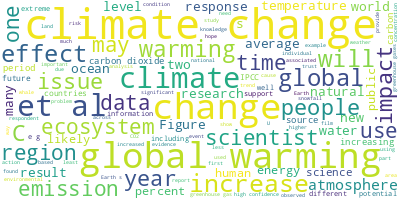

In [ ]:
# Import the wordcloud library
from wordcloud import WordCloud

# Join the different processed titles together.
long_string = ','.join(list(data['Book_Text'].values))

# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=2000, contour_width=3, contour_color='steelblue')

# Generate a word cloud
wordcloud.generate(long_string)

# Visualize the word cloud
wordcloud.to_image()

# Text without cleansing

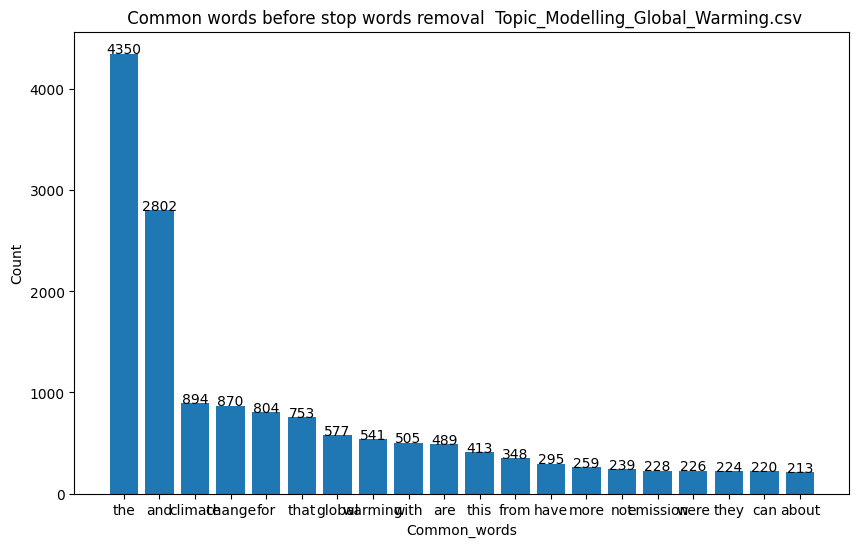

In [ ]:
def Text_with_stop_words(text):
    text = str(text).lower() # converting to lower
    text = " ".join([contractions.fix(expanded_word) for expanded_word in text.split()]) #Removing contractions
    text = re.sub('\[.*?\]', '', text) # Removing text in square brackets
    text = re.sub('https?://\S+|www\.\S+', '', text) #Removing links
    text = re.sub('[^a-zA-Z ]', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(punctuation), '', text) #Removing Punctuations
    text = re.sub('\w*\d\w*', '', text) #Removing words containing numbers
    text = re.sub('\b\w{1,3}\b', '', text) #Any words less than 3 characters are replaced by blanks
    #print(text)
    tokenized_text = word_tokenize(str(text)) # Tokenizing text
    text = [lemmatizer.lemmatize(word) for word in tokenized_text] #Lemmatization
    text = ' '.join(text)
    text = ' '.join(words for words in text.split() if len(words)>2)
    text = re.sub("[\U0001F600-\U0001F64F]", '', text) # removing all emojis form the text
    return text
data['Text_with_stop_words'] = data['Book_Text'].apply(lambda x : Text_with_stop_words(x))

Raw_Text_df = ' '.join(data['Text_with_stop_words'])
token_data = word_tokenize(str(Raw_Text_df))
top = Counter(word for word in token_data)
temp_df_before_cleansing = pd.DataFrame(top.most_common(20))
temp_df_before_cleansing.columns = ['Common_Words','Count']
temp_df_before_cleansing.style.background_gradient(cmap = 'Blues')

def addlabels(x,y):
    for i in range(len(x)):
        plt.text(i, y[i], y[i], ha = 'center')
x = temp_df_before_cleansing['Common_Words']
y = temp_df_before_cleansing['Count']
plt.figure(figsize = (10,6))
plt.title( " Common words before stop words removal  " + file_name)
plt.xlabel("Common_words")
plt.ylabel("Count")
plt.bar(x,y)
addlabels(x, y)
plt.show()

# Data Cleansing

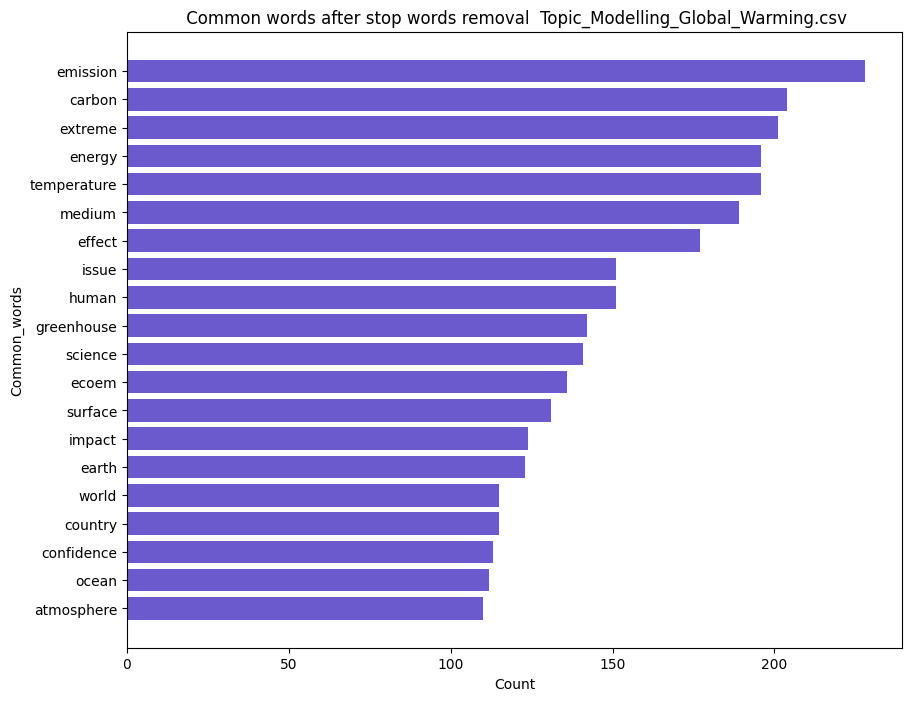

In [ ]:
def Clean_Text(text):
    text = str(text).lower() # converting to lower
    text = " ".join([contractions.fix(expanded_word) for expanded_word in text.split()]) #Removing contractions
    text = re.sub('\[.*?\]', '', text) # Removing text in square brackets
    text = re.sub('https?://\S+|www\.\S+', '', text) #Removing links
    text = re.sub('[^a-zA-Z ]', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(punctuation), '', text) #Removing Punctuations
    text = re.sub('\w*\d\w*', '', text) #Removing words containing numbers
    text = re.sub('\b\w{1,3}\b', '', text) #Any words less than 3 characters are replaced by blanks
    text = ' '.join(words for words in text.split() if len(words)>3)
    #print(text)
    tokenized_text = word_tokenize(str(text)) # Tokenizing text
    filtered_text = [word for word in tokenized_text if word not in stopwords.words('english')] #Removing stopwords
    text = [lemmatizer.lemmatize(word) for word in filtered_text] #Lemmatization
    text = ' '.join(text)
    text = ' '.join(words for words in text.split() if len(words)>3)
    text = re.sub("ecoem|data|result|abstract|change|climate|global|warming|people|considers|defined|since|upon|bnpp|defines|state|area|source|explain|albedo|hope|anger|mirth|satire|however|respondent|inion|knowledge|variable|film|story|action|humor|ecoem|humour|group|bloom|drama|action|said|irena|update|indicator|modification|estimate|scientist|flux|news|program|trust|including|increase|united|america|type|community|city|region|proposed|followed|home|microsote|search|enter|term|recognition|significant|widespread|microsite|recent|education|phenomenon|logo|privacy|sage|model|understanding|attempt|wear|photo|istockjamesteohart|psychological|consideration|political|mammuth|come|savingwould|ever|come|ecoem|solution|aspect|research|using|conclusion|conclude|paper|average|syst|website|microsote|english|czech|esky|david|scale|example|event|percent|mean|meaning|ecoem|year|begin|time|public|work|cooking|cookie|facebook|instagram|order|free|charge|report|assessment|annie|simply|specific|last|activity|refer|contain|browse|changing|like|associated|google|scholar|include|oxford|press|indicates|various|near|detailed|indicate|times|turn|review|scientific|evidence|urgently|sought|attend|generate|sprattunsplashyear|need|but|article|ipsl|skip|content|journal|ipcc|browse|cart|near|far|many|dereczynski|brazil|alejandro|luca|australiacanadaargentinacome|almost|various|role|primarily|uptake|many|brief|main|review|near|reported|common|reporting|format|unfccc|includes|level|could|access|describe|described|pier|forster|christopher|smith|tristram|walsh|lamb|robin|lamboll|mathias|hauser|aurlien|ribes|debbie|rosen|nathan|gillett|matw|palmer|joeri|rogelj|karina|schuckmann|london|germany|france|policy|role|deutsch|sonia|would|should|might|become|may|random|section|study|figure|chapter|index|bibliographical|bibliography|exercise|summary|references|introduction|page|author|reference|title|number|pages|number|embedded system robotics designing simulation matlab simulation aeromodelling month week industrial training major minor project thesis strobotix chandigarh|therefore|either|other|study|project|with|which|will|their|given|also|over|does|more|nadh|although|the|what|none|that|thorough|often|occurs|note|university|college|lecture","",text) #Removing the unused words commonly found in books
    text = re.sub("[\U0001F600-\U0001F64F]", '', text) # removing all emojis form the text
    text = ' '.join(words for words in text.split() if len(words)>3)
    return text
data['clean_text'] = data['Book_Text'].apply(lambda x : Clean_Text(x))

Cleansed_Text_df = ' '.join(data['clean_text'])
token_data = word_tokenize(str(Cleansed_Text_df))
top = Counter(word for word in token_data)
words = ' '.join(top)
count_words = len(words)
temp_df_after_cleansing = pd.DataFrame(top.most_common(20))
temp_df_after_cleansing.columns = ['Common_Words','Count']
temp_df_after_cleansing.style.background_gradient(cmap = 'Blues')

x = temp_df_after_cleansing['Common_Words']
y = temp_df_after_cleansing['Count']
plt.figure(figsize = (10,8))
#indexes = np.arange(len(y))
plt.title( " Common words after stop words removal  " + file_name)
plt.xlabel("Count")
plt.ylabel("Common_words")
plt.barh( x,y, color = 'slateblue')
plt.gca().invert_yaxis()
#addlabels(x, y)
plt.show()

# Word cloud visualization after data cleansing

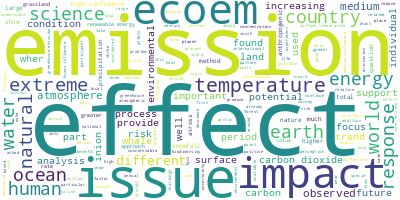

In [ ]:
long_string = ','.join(list(data['clean_text'].values))
wordcloud = WordCloud(background_color="white", max_words=5000, contour_width=3, contour_color='steelblue')
wordcloud.generate(long_string)
wordcloud.to_image()

# Implementation using BerTopic

In [ ]:
start = time.perf_counter()
# Initiate UMAP
umap_model = UMAP(n_neighbors=30,
                  n_components=5,
                  min_dist=0.0,
                  metric='cosine',
                  random_state=150)


In [ ]:
kmeans_model = KMeans(n_clusters=6)

In [ ]:
sentence_model = SentenceTransformer("paraphrase-albert-small-v2")

In [ ]:
# Initiate a pretrained model
hf_model = pipeline("feature-extraction", model="distilroberta-base")

In [ ]:
# Initiate a pretrained embedding model
roberta_model = TransformerDocumentEmbeddings('roberta-base')

In [ ]:
# Initiate another pretrained embedding model
glove_embedding = WordEmbeddings('crawl') #FastText embeddings over Web crawls
document_glove_embeddings = DocumentPoolEmbeddings([glove_embedding])

In [ ]:
# Stack the two pretrained embedding models
stacked_embeddings = StackedEmbeddings(embeddings=[roberta_model,
document_glove_embeddings])

In [ ]:
# Count vectorizer
vectorizer_model = CountVectorizer(min_df=10)

In [ ]:
# Initiate BERTopic
topic_model = BERTopic(umap_model=umap_model, language="english", calculate_probabilities=True,hdbscan_model=kmeans_model, n_gram_range=(1, 3))

In [ ]:
# Run BERTopic model
topics, probabilities = topic_model.fit_transform(data['clean_text'])#abstract_lemmatized
elapsed_time = time.perf_counter() - start
print("Elapsed time is %.2f seconds." %elapsed_time)

Elapsed time is 47.61 seconds.


## Topic List

In [ ]:
# Get the list of topics
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,5,0_whale_carbon_ocean_temperature,"[whale, carbon, ocean, temperature, water, car...",[greenhouse mitigate negative consequence emis...
1,1,4,1_emission_carbon_greenhouse_planet,"[emission, carbon, greenhouse, planet, earth, ...",[improvement quality life world population gon...
2,2,4,2_medium_science_issue_effect,"[medium, science, issue, effect, conservative,...",[analyse reason make sense humanmade important...
3,3,3,3_ecoem_issue_biodiversity_thought,"[ecoem, issue, biodiversity, thought, potentia...",[environmental issue cause consequence issue p...
4,4,3,4_grassland_snowfall_atmosphere_surface,"[grassland, snowfall, atmosphere, surface, col...",[affect terrestrial ecoem induced terrestrial ...
5,5,3,5_energy_confidence_extreme_high confidence,"[energy, confidence, extreme, high confidence,...",[renewable energy national june international ...


In [ ]:
# Get top 10 terms for a topic
topic_model.get_topic(0)

[('whale', 0.021640938107317962),
 ('carbon', 0.0185243412840892),
 ('ocean', 0.016910883153687047),
 ('temperature', 0.012079966154318278),
 ('water', 0.0116178768637988),
 ('carbon dioxide', 0.01131199133354426),
 ('dioxide', 0.011284768678208839),
 ('marine', 0.010626935158873287),
 ('risk', 0.010163019921200932),
 ('world', 0.009175889072810363)]

## Topic Visualization

In [ ]:
# Visualize top topic keywords
topic_model.visualize_barchart(top_n_topics=5)

## Term Rank Decrease

In [ ]:
# Visualize term rank decrease
topic_model.visualize_term_rank()

## Visualizing intertopic distance map

In [ ]:
# Visualize intertopic distance
topic_model.visualize_topics()

## Visualizing topic hierarchy

In [ ]:
# Visualize connections between topics using hierachical clustering
topic_model.visualize_hierarchy(top_n_topics=5)

## Visualizing Similarity Matrix

In [ ]:
# Visualize similarity using heatmap
topic_model.visualize_heatmap()

## Topic Prediction

In [ ]:
# Get the topic predictions
topic_prediction = topic_model.topics_[:]
# Save the predictions in the dataframe
data['topic_prediction'] = topic_prediction
# Take a look at the data
data.head()

,Book_Text,Text_with_stop_words,clean_text,topic_prediction
0,Abstract. This chapter considers psychological...,abstract this chapter considers psychological ...,environmental issue cause consequence issue ps...,3
1,Global Warming is defined as the increase of t...,global warming defined the increase the averag...,temperature earth earth getting hotter disaste...,1
2,1. Climate change can be a natural process whe...,climate change can natural process where tempe...,natural process temperature rainfall wind elem...,0
3,"Earth Syst. Sci. Data, 15, 22952327, 2023\nht...",earth syst sci data author this work distribut...,earth distried creative attriion license annua...,1
4,world ocean review\nUrgently sought  ways out...,world ocean review urgently sought way out the...,world ocean crisis ocean champion boost marine...,0


## Review with new data

In [ ]:
# New data for the review
new_review = "Solution for global warming is natural calamities. It also has huge causes in future"
# Find topics
num_of_topics = 4
similar_topics, similarity = topic_model.find_topics(new_review, top_n=num_of_topics);
# Print results
print(f'The top {num_of_topics} similar topics are {similar_topics}, and the similarities are {np.round(similarity,2)}')

The top 4 similar topics are [1, 0, 3, 4], and the similarities are [0.5  0.5  0.43 0.31]


In [ ]:
# Print the top keywords for the top similar topics
for i in range(num_of_topics):
  print(f'The top keywords for topic {similar_topics[i]} are:')
  print(topic_model.get_topic(similar_topics[i]))

The top keywords for topic 1 are:
[('emission', 0.03848563755964266), ('carbon', 0.014407682497235699), ('greenhouse', 0.014220457895440448), ('planet', 0.014107226799072602), ('earth', 0.013597926729898681), ('world', 0.013075393101353482), ('temperature', 0.010744250897465663), ('footprint', 0.010668601204227083), ('human', 0.00935962940895304), ('food', 0.009335469984491583)]
The top keywords for topic 0 are:
[('whale', 0.021640938107317962), ('carbon', 0.0185243412840892), ('ocean', 0.016910883153687047), ('temperature', 0.012079966154318278), ('water', 0.0116178768637988), ('carbon dioxide', 0.01131199133354426), ('dioxide', 0.011284768678208839), ('marine', 0.010626935158873287), ('risk', 0.010163019921200932), ('world', 0.009175889072810363)]
The top keywords for topic 3 are:
[('ecoem', 0.03337213798264391), ('issue', 0.023275509191852905), ('biodiversity', 0.012397446175679132), ('thought', 0.010499477878059011), ('potential', 0.01014218747732885), ('resilience', 0.009468327501

## Save and load Topic Model

In [ ]:
# Save the topic model
topic_model.save("Global_Warming_topic_model")
# Load the topic model
my_model = BERTopic.load("Global_Warming_topic_model")

2024-04-14 19:16:58,265 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
